# 🔍 Patient Pathway Analysis — SQL Analysis & Healthcare KPIs

**Objective:** Explore the patient cohort through SQL queries — descriptive statistics, healthcare utilisation, and temporal pathway reconstruction using window functions.

**Data source:** `../database/patient_journey.db` (built in `01_exploration.ipynb`)  
**Stack:** Python · pandas · SQLite · matplotlib  

---
**Analysis sections:**
1. Population overview (demographics)
2. Clinical analytics (JOINs · KPIs)
3. Temporal analysis (window functions: ROW_NUMBER, LAG, RANK)
4. Summary

# 1. Imports & Database Connection

In [33]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

conn = sqlite3.connect("../database/patient_journey.db")
print("✅ Connected to patient_journey.db")

✅ Connected to patient_journey.db


# 2. Population Overview

Basic demographic profile of the cohort: patient count, gender distribution, age.

## 2.1 Total number of patients

In [2]:
nb_patients = pd.read_sql("""
    SELECT COUNT(*) AS nb FROM patients;
""", conn).iloc[0, 0]

print(f"Total patients in the dataset: {nb_patients:,}")

Total patients in the dataset: 1,146


## 2.2 Top 20 common pathologies

In [13]:
print("=== Top pathologies===")
top_pathologies = pd.read_sql("""
    SELECT condition_name, COUNT(*) AS frequence
    FROM conditions
    GROUP BY condition_name
    ORDER BY frequence DESC
    LIMIT 21;
""", conn)

print("--- Top 20 most common pathologies in the SQL database patient_journey ---\n")
display(top_pathologies)

=== Top pathologies===
--- Top 20 most common pathologies in the SQL database patient_journey ---



,condition_name,frequence
0,Medication review due (situation),8039
1,Stress (finding),3173
2,Gingivitis (disorder),3086
3,Full-time employment (finding),2977
4,Part-time employment (finding),1809
5,Viral sinusitis (disorder),1161
6,Social isolation (finding),1147
7,Limited social contact (finding),1146
8,Not in labor force (finding),1049
9,Gingival disease (disorder),881


## 2.3 Gender distribution

Male patients  : 583
Female patients: 563


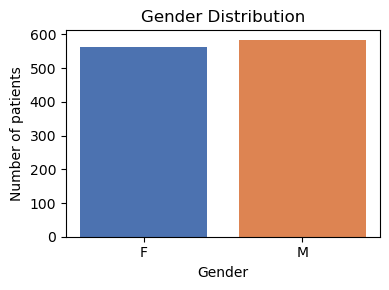

In [34]:
gender = pd.read_sql("""
    SELECT gender, COUNT(*) AS nb
    FROM patients
    GROUP BY gender;
""", conn)

male   = gender.loc[gender["gender"] == "M", "nb"].values[0]
female = gender.loc[gender["gender"] == "F", "nb"].values[0]

print(f"Male patients  : {male:,}")
print(f"Female patients: {female:,}")

plt.figure(figsize=(4, 3))
plt.bar(gender["gender"], gender["nb"], color=["#4C72B0", "#DD8452"])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of patients")
plt.tight_layout()
plt.savefig("../plots/gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()



## 2.4 Age distribution

Average age: 44.5 years
Median age : 44.9 years


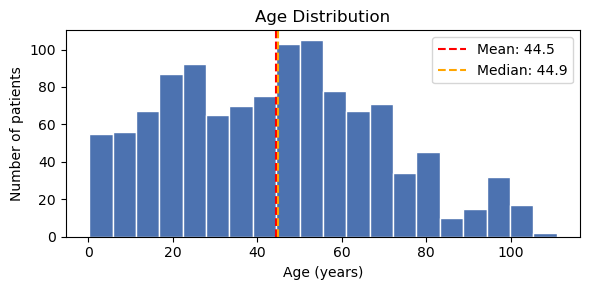

In [39]:
avg_age = pd.read_sql("""
    SELECT AVG((julianday('now') - julianday(birth_date)) / 365.25) AS avg_age
    FROM patients;
""", conn).iloc[0, 0]

ages = pd.read_sql("""
    SELECT (julianday('now') - julianday(birth_date)) / 365.25 AS age
    FROM patients;
""", conn)

median_age = ages["age"].median()  
print(f"Average age: {avg_age:.1f} years")
print(f"Median age : {median_age:.1f} years")

plt.figure(figsize=(6, 3))
plt.hist(ages["age"], bins=20, color="#4C72B0", edgecolor="white")
plt.axvline(avg_age, color="red", linestyle="--", label=f"Mean: {avg_age:.1f}")
plt.axvline(median_age, color="orange", linestyle="--", label=f"Median: {median_age:.1f}")
plt.title("Age Distribution")
plt.xlabel("Age (years)")
plt.ylabel("Number of patients")
plt.legend()
plt.tight_layout()
plt.savefig("../plots/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Clinical Analytics — JOINs & Healthcare KPIs

We join tables to compute key indicators: visits per patient, top healthcare consumers, chronic patients.

## 3.1 Healthcare visits per patient

Patients with at least one encounter: 1,146
Average visits per patient          : 58.6


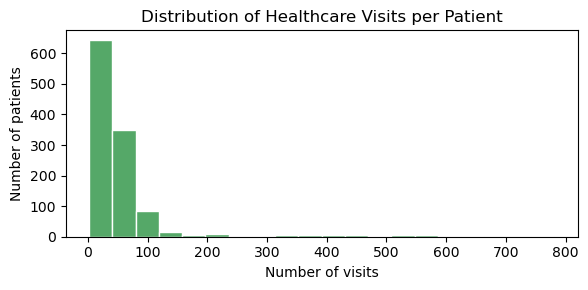

In [36]:
visits = pd.read_sql("""
    SELECT patient_id, COUNT(*) AS nb_visits
    FROM encounters
    GROUP BY patient_id
    ORDER BY nb_visits DESC;
""", conn)

total_patients_with_visits = visits.shape[0]
avg_visits = visits["nb_visits"].mean()

print(f"Patients with at least one encounter: {total_patients_with_visits:,}")
print(f"Average visits per patient          : {avg_visits:.1f}")

plt.figure(figsize=(6, 3))
plt.hist(visits["nb_visits"], bins=20, color="#55A868", edgecolor="white")
plt.title("Distribution of Healthcare Visits per Patient")
plt.xlabel("Number of visits")
plt.ylabel("Number of patients")
plt.tight_layout()
plt.savefig("../plots/healthcare_visits.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.2 Patient ranking by healthcare intensity (RANK)

Most frequent patient: 781 visits (rank #1)
=== Top 10 healthcare users ===


,patient_id,nb_visits,patient_rank
0,2fd1ca31-f06a-6a16-9fcd-0dae28b766af,781,1
1,bf41225b-25ba-ed93-8ed2-665a7f6dbea9,747,2
2,c18c342b-29f6-33c6-0f13-4204ce62c908,656,3
3,7eef5466-9f05-2567-cdfb-79990341f049,641,4
4,38d55e10-9a70-dc15-0cfe-8049a6b7a58b,624,5
5,853b9147-7ef9-6283-41d3-adf6bd72ce12,597,6
6,7b1ba9c4-da53-d15b-e45d-75f2ef6cb328,587,7
7,3dce9c88-b743-607c-e601-212190d46d21,582,8
8,d7dea231-a30c-d995-e581-9421514e1408,577,9
9,83f78184-b4a9-6d95-a945-0a8abde2412c,567,10


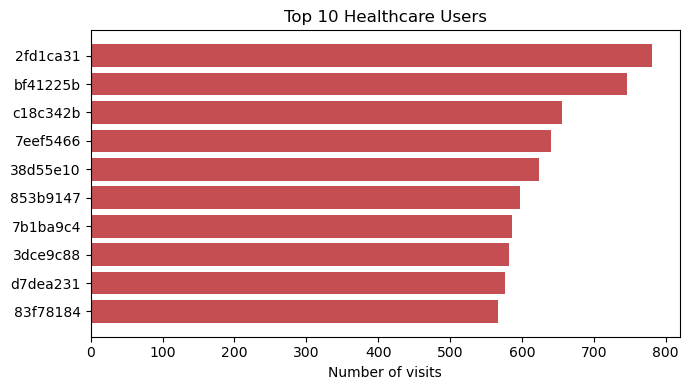

In [37]:
ranking = pd.read_sql("""
    SELECT
        patient_id,
        COUNT(*) AS nb_visits,
        RANK() OVER (ORDER BY COUNT(*) DESC) AS patient_rank
    FROM encounters
    GROUP BY patient_id;
""", conn)

top_ranked = ranking.iloc[0]
print(f"Most frequent patient: {top_ranked['nb_visits']} visits (rank #{int(top_ranked['patient_rank'])})")


print("=== Top 10 healthcare users ===")
top_10_patients = ranking.head(10)
display(ranking.head(10))

plt.figure(figsize=(7, 4))
y_labels = [
    f"#{int(row['patient_rank'])} - {row['patient_id'][:8]}"
    for _, row in top_10_patients.iterrows()
]
plt.barh(
    top_10_patients["patient_id"].str[:8],
    top_10_patients["nb_visits"],
    color="#C44E52",
)
plt.gca().invert_yaxis()
plt.title("Top 10 Healthcare Users")
plt.xlabel("Number of visits")
plt.tight_layout()
plt.savefig("../plots/healthcare_ranking.png", dpi=300, bbox_inches="tight")
plt.show()


## 3.3 Patients with multiple chronic conditions (5+ distinct conditions)

**Methodological Note on Threshold Selection:** An initial review of the raw outputs highlighted two main characteristics in the dataset that required adjusting our logic:

    1. Longitudinal Duplication: The raw conditions table captures a patient's entire history, meaning the same chronic diagnosis (e.g., Type 2 Diabetes) is often logged repeatedly across multiple healthcare encounters. Counting raw rows would artificially inflate clinical complexity—misleadingly showing top patients with over 400 conditions. To isolate unique medical issues, we apply a COUNT(DISTINCT condition_name) constraint.

    2. Threshold Justification: Synthea tracks not only severe chronic illnesses but also acute minor issues (common colds) and social observations. While literature often uses 2+ conditions to define multimorbidity, applying that here would include nearly the entire cohort. Raising our target to 5 or more distinct conditions allows us to isolate a highly relevant, genuinely complex subpopulation for healthcare intensity analysis.

Patients with 5+ conditions (Complex Multimorbidity): 1,093
Proportion of total cohort                           : 95.4%


,patient_id,nb_conditions
0,c26040e8-78f8-f9bf-9472-a72cfa919387,60
1,51c0940d-4629-c0ab-67cd-52b4a8d8c270,57
2,1c6b6529-99a7-943e-42e0-ac130b4da65f,57
3,45aba5f2-e292-22ec-8fbc-5abcc89c5207,55
4,8c122072-1bb9-7100-424a-7ed32b56d225,54
5,d6e6d100-1cd3-2122-3c8b-f20e216e6b50,53
6,001a4e81-6358-a7ad-8261-7ea6752ab0cf,53
7,0982d397-8d91-2314-674c-b26825195fdf,51
8,d7dea231-a30c-d995-e581-9421514e1408,50
9,131135be-1205-86b1-a73d-4179168cb161,50


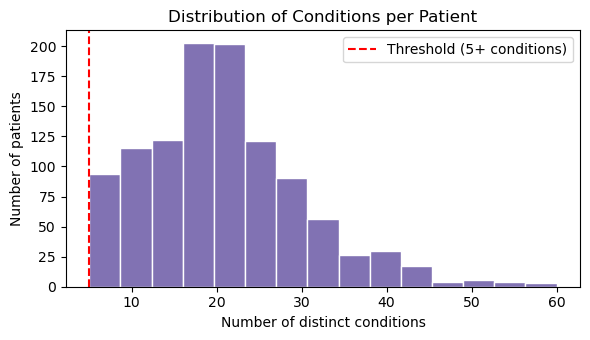

In [38]:
chronic_patients = pd.read_sql("""
    SELECT patient_id, COUNT(DISTINCT condition_name) AS nb_conditions
    FROM conditions
    GROUP BY patient_id
    HAVING nb_conditions >= 5
    ORDER BY nb_conditions DESC;
""", conn)

complex_patients = chronic_patients[chronic_patients["nb_conditions"] >= 5]
nb_chronic = complex_patients.shape[0]
pct_chronic = (nb_chronic / nb_patients) * 100

print(f"Patients with 5+ conditions (Complex Multimorbidity): {nb_chronic:,}")
print(f"Proportion of total cohort                           : {pct_chronic:.1f}%")

display(complex_patients.head(10))

plt.figure(figsize=(6, 3.5))
plt.hist(chronic_patients["nb_conditions"], bins=15, color="#8172B3", edgecolor="white")
plt.axvline(5, color="red", linestyle="--", linewidth=1.5, label="Threshold (5+ conditions)")
plt.title("Distribution of Conditions per Patient")
plt.xlabel("Number of distinct conditions")
plt.ylabel("Number of patients")
plt.legend()
plt.tight_layout()
plt.savefig("../plots/complex_patients.png", dpi=300, bbox_inches="tight")
plt.show()



# 4. Temporal Analysis — Window Functions

We reconstruct individual care pathways using SQL window functions: 
`ROW_NUMBER()` to order visits chronologically and `LAG()` to compute the time elapsed between consecutive visits.

## 4.1 Visit chronology per patient (ROW_NUMBER)

In [20]:
visit_order = pd.read_sql("""
    SELECT
        patient_id,
        encounter_date,
        ROW_NUMBER() OVER (
            PARTITION BY patient_id
            ORDER BY encounter_date
        ) AS visit_order
    FROM encounters;
""", conn)

print("Visit chronology (first 10 rows):")
display(visit_order.head(10))

Visit chronology (first 10 rows):


,patient_id,encounter_date,visit_order
0,001a4e81-6358-a7ad-8261-7ea6752ab0cf,1968-12-10T10:04:48Z,1
1,001a4e81-6358-a7ad-8261-7ea6752ab0cf,1969-12-16T10:04:48Z,2
2,001a4e81-6358-a7ad-8261-7ea6752ab0cf,1976-12-28T10:04:48Z,3
3,001a4e81-6358-a7ad-8261-7ea6752ab0cf,1980-01-01T10:04:48Z,4
4,001a4e81-6358-a7ad-8261-7ea6752ab0cf,1981-03-20T10:04:48Z,5
5,001a4e81-6358-a7ad-8261-7ea6752ab0cf,1981-05-26T10:04:48Z,6
6,001a4e81-6358-a7ad-8261-7ea6752ab0cf,1995-11-07T10:04:48Z,7
7,001a4e81-6358-a7ad-8261-7ea6752ab0cf,1996-11-12T10:04:48Z,8
8,001a4e81-6358-a7ad-8261-7ea6752ab0cf,2006-10-23T10:31:19Z,9
9,001a4e81-6358-a7ad-8261-7ea6752ab0cf,2008-02-04T11:14:53Z,10


## 4.2 Time between visits (LAG)

Average time between two visits: 195.9 days


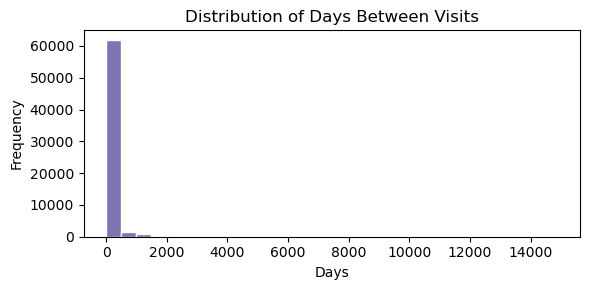

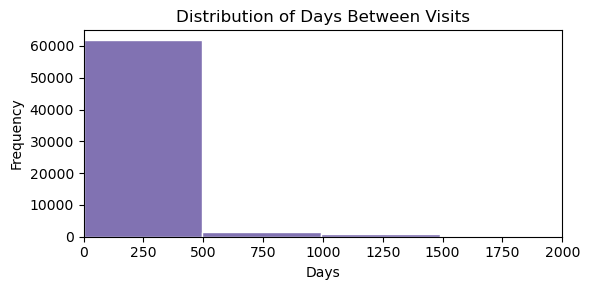

In [25]:

time_between_visits = pd.read_sql("""
    SELECT
        patient_id,
        encounter_date,
        JULIANDAY(encounter_date) -
        JULIANDAY(LAG(encounter_date) OVER (
            PARTITION BY patient_id
            ORDER BY encounter_date
        )) AS days_between_visits
    FROM encounters;
""", conn)

avg_delay = time_between_visits["days_between_visits"].mean()
print(f"Average time between two visits: {avg_delay:.1f} days")

plt.figure(figsize=(6, 3))
plt.hist(time_between_visits["days_between_visits"].dropna(), bins=30,
         color="#8172B2", edgecolor="white")
plt.title("Distribution of Days Between Visits")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../plots/time_between_visit.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 3))
plt.hist(time_between_visits["days_between_visits"].dropna(), bins=30,
         color="#8172B2", edgecolor="white")
plt.title("Distribution of Days Between Visits")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.xlim(0, 2000)
plt.tight_layout()
plt.savefig("../plots/time_between_visit_max2000.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Summary

This notebook successfully reconstructed patient care pathways from a relational database using SQL.

| Indicator | Value |
|-----------|-------|
| Patients with encounters | 1146 |
| Average visits per patient | 58.6 |
| Chronic patients (≥5 conditions) | 1.093 (95.4%) |
| Average delay between visits | 195.9 days |

**Key SQL techniques used:** `GROUP BY`, `HAVING`, `JOIN`, `ROW_NUMBER()`, `LAG()`, `RANK()`, `COUNT(DISTINCT)`

**Limitations:** The Synthea dataset is synthetic; patterns may not reflect real clinical populations. Furthermore, the extreme density of longitudinal condition tracking required strict distinct counting to isolate true clinical complexity.

**Next step:** `03_statistical_analysis.ipynb` - hypothesis testing and regression.

In [32]:
print(f"""
=== COHORT SUMMARY ===

Total patients                                       : {nb_patients:,}
  Male                                               : {male:,}
  Female                                             : {female:,}
Average age                                          : {avg_age:.1f} years
Patients with visits                                 : {total_patients_with_visits:,}
Average visits/patient                               : {avg_visits:.1f}
Avg delay between visits                             : {avg_delay:.1f} days
Complex chronic patients (5+ distinct conditions)  : {nb_chronic:,} ({pct_chronic:.1f}%)
""")


=== COHORT SUMMARY ===

Total patients                                       : 1,146
  Male                                               : 583
  Female                                             : 563
Average age                                          : 44.5 years
Patients with visits                                 : 1,146
Average visits/patient                               : 58.6
Avg delay between visits                             : 195.9 days
Complex chronic patients (>= 5 distinct conditions)  : 1,093 (95.4%)

